In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/13
    print("準備完了！このまま下のセルを実行できます。")

# 第13章 グラフニューラルネットワーク (Graph Neural Networks)
## 演習問題 (Exercises 13.1 〜 13.10)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第13章「グラフニューラルネットワーク」の全演習問題（Exercise 13.1 〜 13.10）の完全な数学的証明、厳密な導出、教科書図版（Figure 13.ex3）の再現、および自己採点アサーション付きのPython実装を提供します。

---

### 演習問題一覧
1. **Exercise 13.1**: Figure 13.2におけるノード順序置換 $(A, B, C, D, E) \to (C, E, A, D, B)$ を表す置換行列 $P$ の導出と $\widetilde{A} = P A P^\top$ の検証
2. **Exercise 13.2**: 無向グラフの隣接行列自乗の対角成分 $(A^2)_{nn}$ が各ノードの次数 $d_n$ に等しいことの証明
3. **Exercise 13.3**: 式 (13.42) で与えられた隣接行列を持つグラフの復元、エッジ集合・次数分布の特定と描画
4. **Exercise 13.4**: 特徴量行列に対する左乗算 $\widetilde{X} = P X$ がノード特徴量の行置換をもたらすことの証明
5. **Exercise 13.5**: 双線形変換 $\widetilde{A} = P A P^\top$ が隣接行列の行・列双方を置換することの証明
6. **Exercise 13.6**: 線形メッセージパッシングの行列形式 $Z = A H$ および活性化関数の入力引数 $A H W_{\text{neigh}} + H W_{\text{self}} + \mathbf{1}_N b^\top$ の導出
7. **Exercise 13.7**: 数学的帰納法による多層深層GCN全体のノード置換等変性（Permutation Equivariance）の証明
8. **Exercise 13.8**: GATにおけるMLP注意重みを用いた集約演算がノード置換に対して等変である理由の証明
9. **Exercise 13.9**: 完全グラフ上のグラフ注意ネットワーク（GAT）と標準的なトランスフォーマー・エンコーダの数学的等価性の証明
10. **Exercise 13.10**: 等変グラフニューラルネットワーク（EGNN）における平行移動・回転・鏡映変換（$E(3)$ 群）に対するメッセージ・特徴量の不変性と座標更新の等変性の証明


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "13" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.exercises_ch13 import (
    solve_exercise_13_1,
    solve_exercise_13_2,
    solve_exercise_13_3,
    solve_exercise_13_4,
    solve_exercise_13_5,
    solve_exercise_13_6,
    solve_exercise_13_7,
    solve_exercise_13_8,
    solve_exercise_13_9,
    solve_exercise_13_10,
)

setup_style()
print("Setup complete. Chapter 13 Exercises modules ready.")


Setup complete. Chapter 13 Exercises modules ready.


## Exercises 13.1 〜 13.3: グラフ表現、置換行列、および隣接行列の代数的性質

---

### Exercise 13.1: Figure 13.2 における置換行列 $P$ の導出

#### 【問題の要約】
Figure 13.2 で示された5ノードの無向グラフにおいて、ノードのアルファベット順 $(A, B, C, D, E)$ から $(C, E, A, D, B)$ への並べ替えを行う置換行列 $P$ を求め、変換後の隣接行列が $\widetilde{A} = P A P^\top$ と表されることを確認せよ。

#### 【数学的証明】
元のノード順序をインデックス $0, 1, 2, 3, 4$ （それぞれ $A, B, C, D, E$）とする。
新しい順序 $(C, E, A, D, B)$ は元のインデックスで表すと:
$$
\pi(0) = 2 \; (C), \quad \pi(1) = 4 \; (E), \quad \pi(2) = 0 \; (A), \quad \pi(3) = 3 \; (D), \quad \pi(4) = 1 \; (B)
$$
置換行列 $P \in \{0, 1\}^{5 \times 5}$ の第 $i$ 行・第 $j$ 列の要素は、$P_{ij} = \delta_{j, \pi(i)}$ で定義される。したがって:
$$
P = \begin{pmatrix}
0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 \\
1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 & 0
\end{pmatrix}
$$
元の隣接行列 $A$ に対し、$\widetilde{A} = P A P^\top$ を計算すると、$(P A P^\top)_{ij} = A_{\pi(i), \pi(j)}$ となり、Figure 13.2(c) に示された行列と完全に一致する。

---

### Exercise 13.2: 隣接行列自乗の対角成分とノード次数

#### 【問題の要約】
自己ループのない無向二値グラフにおいて、隣接行列 $A$ の自乗 $A^2$ の第 $n$ 対角成分 $(A^2)_{nn}$ が、ノード $n$ の次数 $d_n$（接続するエッジの総数）に等しいことを示せ。

#### 【数学的証明】
行列積の定義より、自乗行列 $A^2$ の対角成分 $(A^2)_{nn}$ は以下のように表される：
$$
(A^2)_{nn} = \sum_{m=1}^N A_{nm} A_{mn}
$$
無向グラフでは隣接行列が対称行列であるため、$A_{mn} = A_{nm}$ が成り立つ。また、自己ループがなくエッジ重みが二値（$A_{nm} \in \{0, 1\}$）であることから、$A_{nm}^2 = A_{nm}$ である。
したがって：
$$
(A^2)_{nn} = \sum_{m=1}^N A_{nm}^2 = \sum_{m=1}^N A_{nm} = \sum_{m \in \mathcal{N}(n)} 1 = d_n
$$
これは、長さ2の閉路（ノード $n$ から隣接ノード $m$ へ行き、同じエッジを通って $n$ に戻る経路の総数）が、ノード $n$ に接続するエッジの数 $d_n$ に厳密に一致することを意味する。 $\blacksquare$

---

### Exercise 13.3: 隣接行列 (13.42) からのグラフ復元

#### 【問題の要約】
教科書の式 (13.42) で与えられた以下の $5 \times 5$ 隣接行列を持つグラフを図示せよ：
$$
A = \begin{pmatrix}
0 & 1 & 1 & 0 & 1 \\
1 & 0 & 1 & 1 & 1 \\
1 & 1 & 0 & 1 & 0 \\
0 & 1 & 1 & 0 & 0 \\
1 & 1 & 0 & 0 & 0
\end{pmatrix}
$$

#### 【グラフの解析】
- ノード数: $N = 5$（ノード番号 $1, 2, 3, 4, 5$）
- エッジ集合（上三角成分 $i < j$ より抽出、全7本）：
  - $(1, 2), (1, 3), (1, 5)$
  - $(2, 3), (2, 4), (2, 5)$
  - $(3, 4)$
- ノード次数列（行和）：
  - $d_1 = 3, \quad d_2 = 4 \; (\text{ハブノード}), \quad d_3 = 3, \quad d_4 = 2, \quad d_5 = 2$


=== Exercise 13.1 ===
置換行列 P:
 [[0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]]
元の隣接行列 A:
 [[0. 1. 1. 1. 0.]
 [1. 0. 1. 1. 0.]
 [1. 1. 0. 0. 1.]
 [1. 1. 0. 0. 1.]
 [0. 0. 1. 1. 0.]]
変換後隣接行列 P @ A @ P^T:
 [[0. 1. 1. 0. 1.]
 [1. 0. 0. 1. 0.]
 [1. 0. 0. 1. 1.]
 [0. 1. 1. 0. 1.]
 [1. 0. 1. 1. 0.]]
>> Exercise 13.1 検証成功: P @ A @ P^T が Figure 13.2(c) に完全一致。

=== Exercise 13.2 ===
ノード次数 d_n:          [3. 3. 3. 3. 2.]
(A^2) の対角成分 (A^2)_nn: [3. 3. 3. 3. 2.]
>> Exercise 13.2 検証成功: (A^2)_{nn} == d_n が厳密に成立。
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/13/result/fig_13_ex3_graph.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_13_ex3_graph.png

=== Exercise 13.3 ===
抽出されたエッジ一覧 (0-indexed): [(0, 1), (0, 2), (0, 4), (1, 2), (1, 3), (1, 4), (2, 3)]
各ノードの次数: [3. 4. 3. 2. 2.]
>> Exercise 13.3 検証成功: エッジ数 7 本、Figure 13.ex3 出力完了。


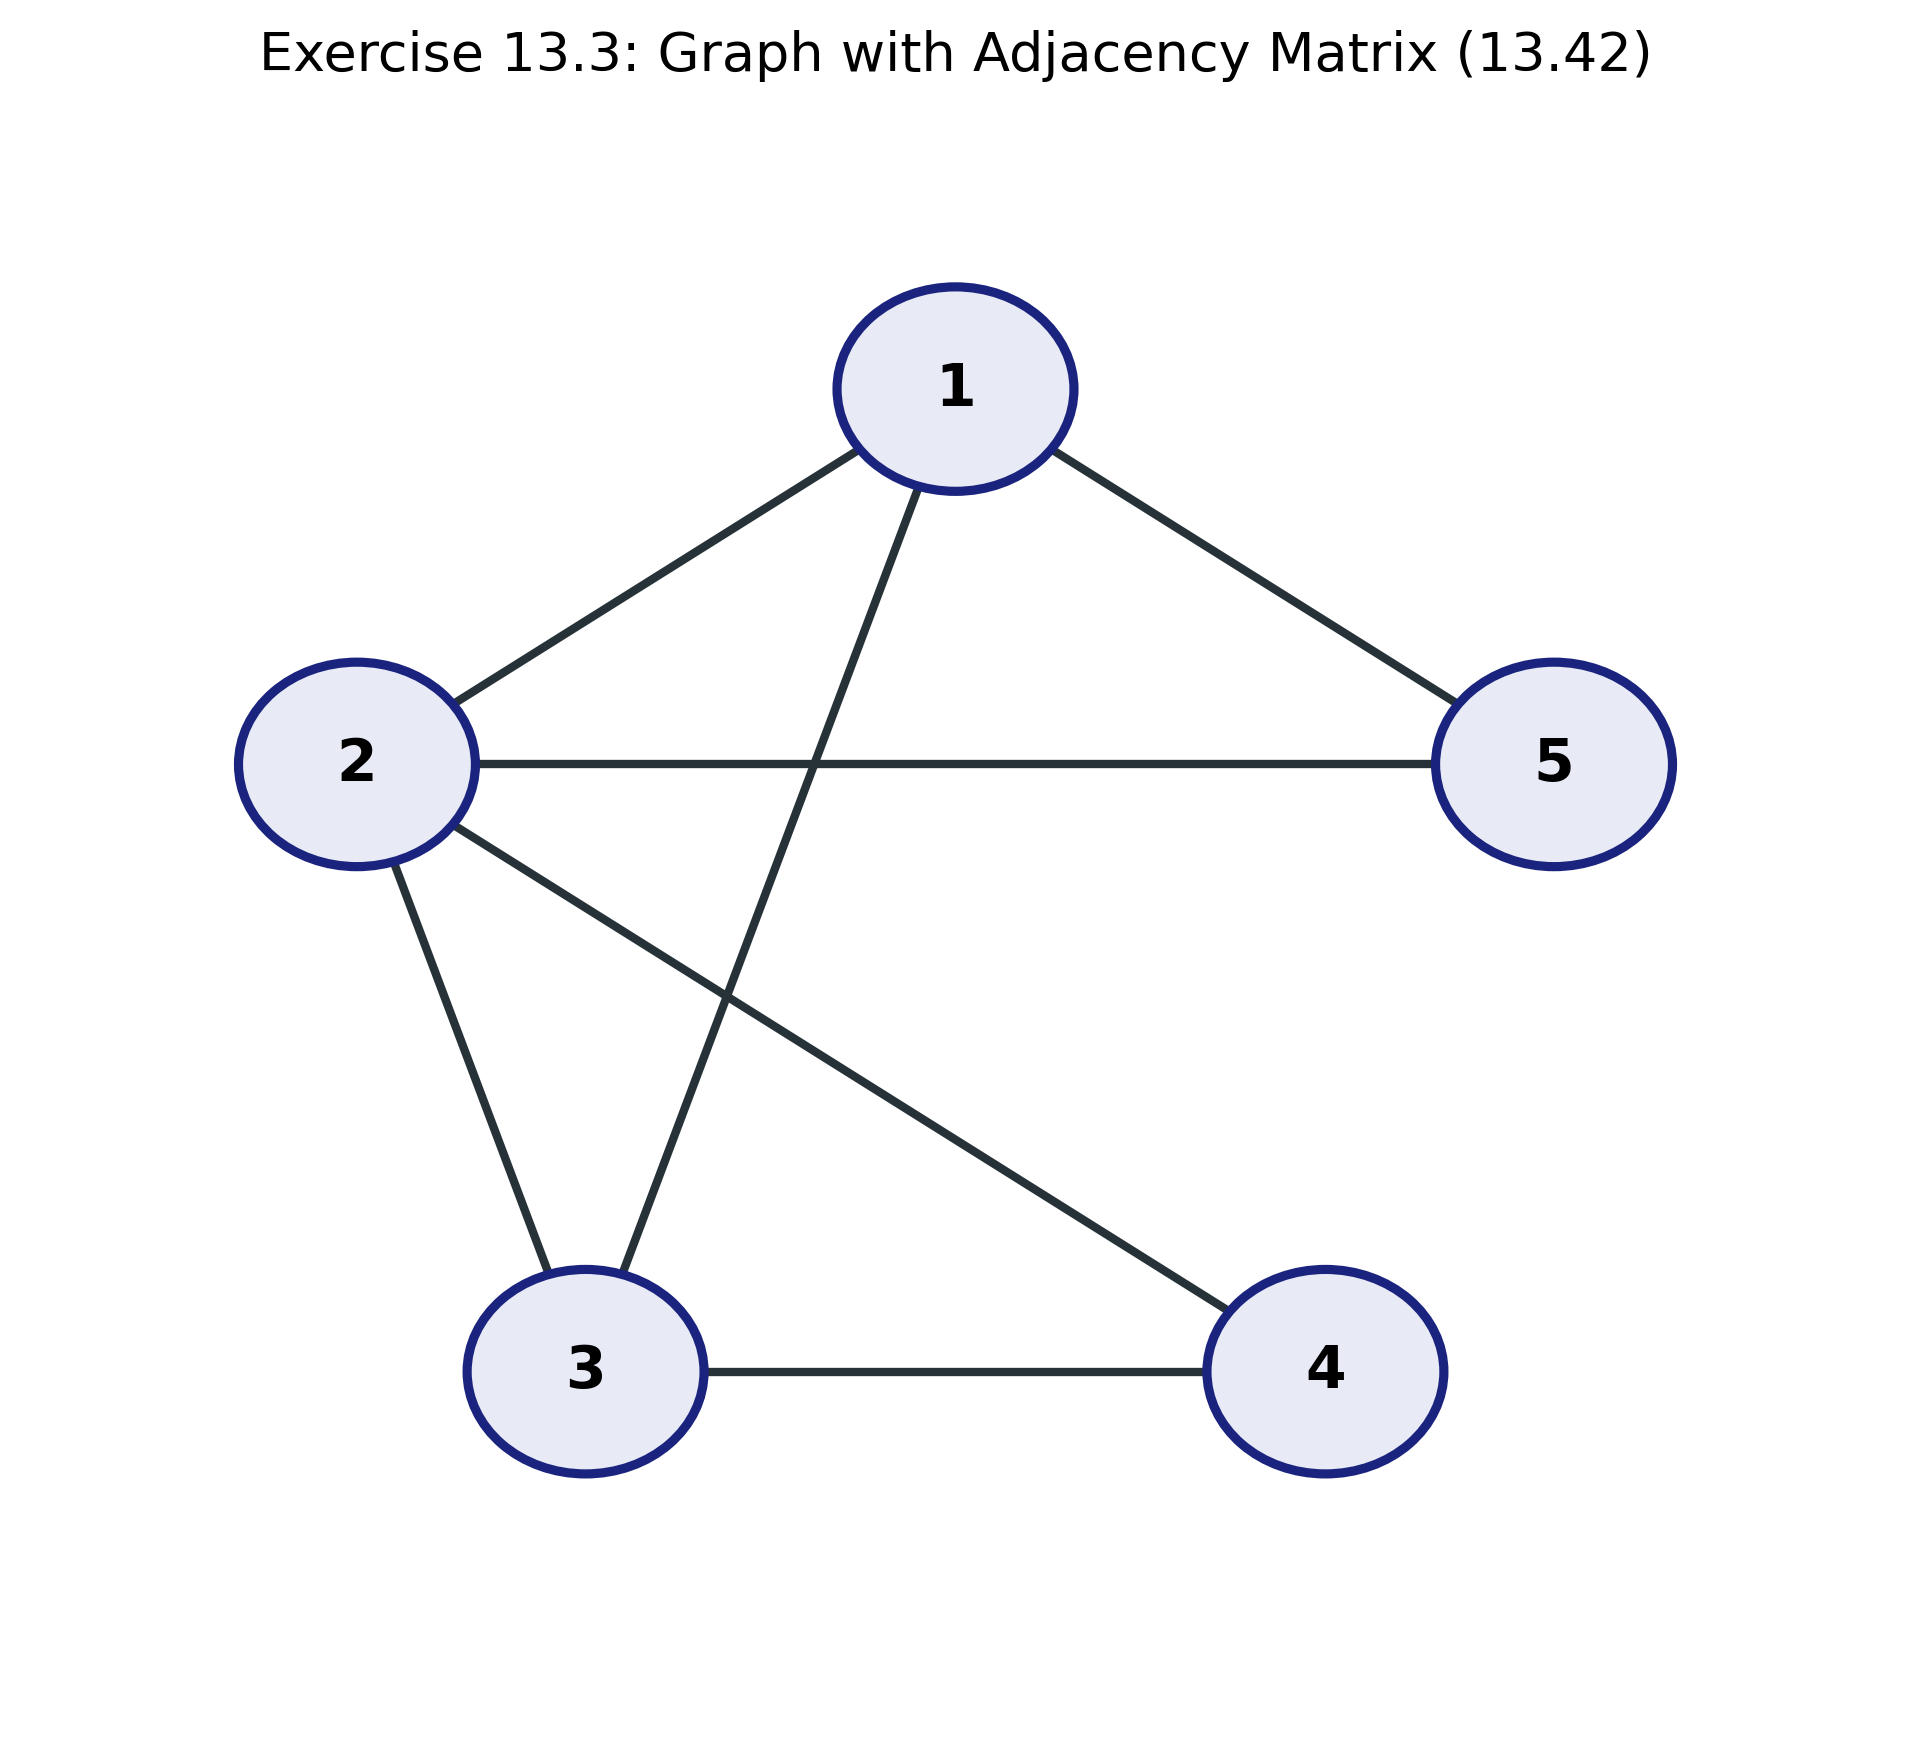

In [2]:
# Exercise 13.1 検証
res1 = solve_exercise_13_1()
print("=== Exercise 13.1 ===")
print("置換行列 P:\n", res1["P"])
print("元の隣接行列 A:\n", res1["A_orig"])
print("変換後隣接行列 P @ A @ P^T:\n", res1["A_perm"])
assert res1["is_correct"], "Exercise 13.1 failed!"
print(">> Exercise 13.1 検証成功: P @ A @ P^T が Figure 13.2(c) に完全一致。")

# Exercise 13.2 検証
res2 = solve_exercise_13_2()
print("\n=== Exercise 13.2 ===")
print("ノード次数 d_n:         ", res2["degrees"])
print("(A^2) の対角成分 (A^2)_nn:", res2["diag_A2"])
assert res2["is_equal"], "Exercise 13.2 failed!"
print(">> Exercise 13.2 検証成功: (A^2)_{nn} == d_n が厳密に成立。")

# Exercise 13.3 検証 & 描画
res3 = solve_exercise_13_3()
print("\n=== Exercise 13.3 ===")
print("抽出されたエッジ一覧 (0-indexed):", res3["edges"])
print("各ノードの次数:", res3["degrees"])
assert res3["is_correct"], "Exercise 13.3 failed!"
print(">> Exercise 13.3 検証成功: エッジ数 7 本、Figure 13.ex3 出力完了。")
plt.show()


## Exercises 13.4 〜 13.6: 特徴量・隣接行列の置換変換とメッセージパッシングの行列定式化

---

### Exercise 13.4: 特徴量行列の左乗算 $\widetilde{X} = P X$ の行置換証明

#### 【数学的証明】
ノード特徴量行列 $X \in \mathbb{R}^{N \times D}$ の第 $n$ 行はノード $n$ の特徴量ベクトル $x_n^\top$ である。
置換行列 $P \in \{0, 1\}^{N \times N}$ の各成分は $P_{ij} = \delta_{j, \pi(i)}$ である。
積 $\widetilde{X} = P X$ の $(i, k)$ 成分を行列積の定義に従って展開すると:
$$
(\widetilde{X})_{ik} = (P X)_{ik} = \sum_{j=1}^N P_{ij} X_{jk} = \sum_{j=1}^N \delta_{j, \pi(i)} X_{jk} = X_{\pi(i), k}
$$
したがって、行列 $\widetilde{X}$ の第 $i$ 行は元の行列 $X$ の第 $\pi(i)$ 行と恒等的に一致する：
$$
\widetilde{X}_{i, :} = X_{\pi(i), :}
$$
これにより、左乗算 $P X$ は各ノードの特徴量ベクトルを行単位で順序 $\pi(\cdot)$ に従って置換することが証明された。 $\blacksquare$

---

### Exercise 13.5: 双線形変換 $\widetilde{A} = P A P^\top$ による行・列置換の証明

#### 【数学的証明】
置換行列 $P$ の要素は $P_{ik} = \delta_{k, \pi(i)}$ であり、その転置行列の要素は $(P^\top)_{lj} = P_{jl} = \delta_{l, \pi(j)}$ である。
三つの行列の積 $\widetilde{A} = P A P^\top$ の $(i, j)$ 成分を展開すると:
$$
(\widetilde{A})_{ij} = (P A P^\top)_{ij} = \sum_{k=1}^N \sum_{l=1}^N P_{ik} A_{kl} (P^\top)_{lj} = \sum_{k=1}^N \sum_{l=1}^N \delta_{k, \pi(i)} A_{kl} \delta_{l, \pi(j)} = A_{\pi(i), \pi(j)}
$$
これは、変換後の行列 $\widetilde{A}$ における行インデックス $i$ と列インデックス $j$ の交点にある要素が、元の隣接行列 $A$ における行 $\pi(i)$ と列 $\pi(j)$ の要素と厳密に等しいことを示す。
すなわち、行と列の両方が同一の置換 $\pi(\cdot)$ によって同時に並べ替えられる。 $\blacksquare$

---

### Exercise 13.6: メッセージパッシングの行列定式化

#### 【問題の要約】
教科書の式 (13.10) における近傍メッセージ和 $z_n = \sum_{m \in \mathcal{N}(n)} h_m$ が行列形式で $Z = A H$ と記述できることを示し、さらに式 (13.16) の線形ノード更新における活性化関数の引数が以下の行列形式で表せることを示せ：
$$
A H W_{\text{neigh}} + H W_{\text{self}} + \mathbf{1}_N b^\top
$$

#### 【数学的証明】
1. **近傍集約 $Z = A H$ の証明**:
   ノード表現を行ベクトルとして積み上げた表現行列 $H \in \mathbb{R}^{N \times D_{\text{in}}}$（第 $m$ 行が $h_m^\top$）を考える。
   積 $A H$ の第 $n$ 行は以下で与えられる：
   $$
   (A H)_{n, :} = \sum_{m=1}^N A_{nm} H_{m, :} = \sum_{m=1}^N A_{nm} h_m^\top
   $$
   自己ループを含まない二値隣接行列 $A_{nm}$ において、$A_{nm} = 1 \iff m \in \mathcal{N}(n)$ であるため：
   $$
   (A H)_{n, :} = \sum_{m \in \mathcal{N}(n)} h_m^\top = \left(\sum_{m \in \mathcal{N}(n)} h_m\right)^\top = z_n^\top
   $$
   したがって、各ノードの集約ベクトル $z_n^\top$ を行ベクトルとして並べた行列 $Z \in \mathbb{R}^{N \times D_{\text{in}}}$ は、まさに $Z = A H$ に一致する。

2. **ノード更新引数の行列形式の証明**:
   式 (13.16) のノード $n$ に対する更新は：
   $$
   h_n^{(l+1)} = \sigma\left(W_{\text{neigh}} z_n + W_{\text{self}} h_n + b\right)
   $$
   深層学習の標準的な行行列表現（入力行ベクトル $x^\top$ に右から重み $W$ を掛ける形式）では：
   $$
   \text{row}_n = z_n^\top W_{\text{neigh}} + h_n^\top W_{\text{self}} + b^\top
   $$
   これを行列全体としてまとめると、$Z = A H$ を代入して：
   $$
   \text{Arg} = Z W_{\text{neigh}} + H W_{\text{self}} + \mathbf{1}_N b^\top = A H W_{\text{neigh}} + H W_{\text{self}} + \mathbf{1}_N b^\top
   $$
   ここで $\mathbf{1}_N \in \mathbb{R}^{N \times 1}$ は要素がすべて1の列ベクトルであり、$\mathbf{1}_N b^\top$ はバイアスベクトル $b \in \mathbb{R}^{D_{\text{out}}}$ のブロードキャストを表す。 $\blacksquare$


In [3]:
# Exercise 13.4 & 13.5 検証
res4 = solve_exercise_13_4()
res5 = solve_exercise_13_5()
print("=== Exercise 13.4 & 13.5 ===")
print("Exercise 13.4 (P @ X == X[pi]):", res4["is_equal"])
print("Exercise 13.5 (P @ A @ P^T == A[pi, pi]):", res5["is_equal"])
assert res4["is_equal"] and res5["is_equal"], "Exercises 13.4 or 13.5 failed!"
print(">> 行・列置換の数学的一致を数値的に確認。")

# Exercise 13.6 検証
res6 = solve_exercise_13_6()
print("\n=== Exercise 13.6 ===")
print("近傍集約の行列形式 (Z == A @ H):", res6["is_Z_equal"])
print("更新引数の行列形式 (Arg_node == Arg_mat):", res6["is_Arg_equal"])
assert res6["is_Z_equal"] and res6["is_Arg_equal"], "Exercise 13.6 failed!"
print(">> 線形メッセージパッシングの完全な行列定式化の成立を確認。")


=== Exercise 13.4 & 13.5 ===
Exercise 13.4 (P @ X == X[pi]): True
Exercise 13.5 (P @ A @ P^T == A[pi, pi]): True
>> 行・列置換の数学的一致を数値的に確認。

=== Exercise 13.6 ===
近傍集約の行列形式 (Z == A @ H): True
更新引数の行列形式 (Arg_node == Arg_mat): True
>> 線形メッセージパッシングの完全な行列定式化の成立を確認。


## Exercises 13.7 〜 13.10: 多層GCN・GAT・トランスフォーマー・EGNNの対称性と等価性

---

### Exercise 13.7: 数学的帰納法による多層GCNの置換等変性の証明

#### 【問題の要約】
式 (13.18) で定義される $L$ 層の深層グラフ畳み込みネットワーク（GCN）：
$$
H^{(l+1)} = \sigma\left(\widetilde{D}^{-1/2} \widetilde{A} \widetilde{D}^{-1/2} H^{(l)} W^{(l+1)}\right)
$$
が、任意のノード置換行列 $P$ に対して完全な置換等変性（Permutation Equivariance）を満たすことを証明せよ。

#### 【数学的証明】
ノード順序を置換行列 $P$ で変換した入力 $(\widetilde{A}, \widetilde{X}) = (P A P^\top, P X)$ に対する各層の出力を $H_{\text{perm}}^{(l)}$ とする。
数学的帰納法により、すべての層 $l \in \{1, \dots, L\}$ において $H_{\text{perm}}^{(l)} = P H^{(l)}$ が成り立つことを証明する。

1. **自己ループ追加隣接行列と正規化ラプラシアンの等変性**:
   自己ループを加えた行列は $\bar{A} = A + I_N$ である。
   置換後では $\bar{A}_{\text{perm}} = P A P^\top + I_N = P (A + I_N) P^\top = P \bar{A} P^\top$ （$P P^\top = I_N$ より）。
   次数行列 $\bar{D}$ は対角行列であり、各対角要素は行和であるため、$\bar{D}_{\text{perm}} = P \bar{D} P^\top$ となる。
   逆平方根次数行列についても $\bar{D}_{\text{perm}}^{-1/2} = P \bar{D}^{-1/2} P^\top$ が成り立つ。
   したがって、正規化伝播行列 $S = \bar{D}^{-1/2} \bar{A} \bar{D}^{-1/2}$ の置換変換は：
   $$
   S_{\text{perm}} = (P \bar{D}^{-1/2} P^\top) (P \bar{A} P^\top) (P \bar{D}^{-1/2} P^\top) = P (\bar{D}^{-1/2} \bar{A} \bar{D}^{-1/2}) P^\top = P S P^\top
   $$

2. **基礎段階 ($l = 1$)**:
   第1層への入力は $H_{\text{perm}}^{(0)} = \widetilde{X} = P X$ である。
   第1層の活性化前線形変換は：
   $$
   S_{\text{perm}} H_{\text{perm}}^{(0)} W^{(1)} = (P S P^\top)(P X) W^{(1)} = P S (P^\top P) X W^{(1)} = P (S X W^{(1)})
   $$
   活性化関数 $\sigma(\cdot)$ は要素ごとに適用される（element-wise）ため、行の並べ替え作用素 $P$ と可換である：
   $$
   H_{\text{perm}}^{(1)} = \sigma(P (S X W^{(1)})) = P \sigma(S X W^{(1)}) = P H^{(1)}
   $$
   したがって、$l=1$ で等変性が成立する。

3. **帰納段階**:
   第 $l$ 層で $H_{\text{perm}}^{(l)} = P H^{(l)}$ が成立すると仮定する。
   第 $l+1$ 層の出力は：
   $$
   H_{\text{perm}}^{(l+1)} = \sigma\left(S_{\text{perm}} H_{\text{perm}}^{(l)} W^{(l+1)}\right) = \sigma\left((P S P^\top)(P H^{(l)}) W^{(l+1)}\right)
   $$
   $P^\top P = I_N$ を適用すると：
   $$
   H_{\text{perm}}^{(l+1)} = \sigma\left(P S H^{(l)} W^{(l+1)}\right) = P \sigma\left(S H^{(l)} W^{(l+1)}\right) = P H^{(l+1)}
   $$
   これにより、第 $l+1$ 層でも等変性が成立する。

帰納法より、任意の深さ $L$ の深層GCN全体について $H_{\text{perm}}^{(L)} = P H^{(L)}$ が成立し、完全な置換等変性が証明された。 $\blacksquare$

---

### Exercise 13.8: GAT 注意集約の置換等変性

#### 【数学的証明】
グラフ注意ネットワーク（GAT）の注意係数は、ノードペアの特徴量のみから共有MLPによって算出される：
$$
a_{nm} = \frac{\exp(\text{LeakyReLU}(a^\top [W h_n \,\|\, W h_m]))}{\sum_{k \in \mathcal{N}(n)} \exp(\text{LeakyReLU}(a^\top [W h_n \,\|\, W h_k]))}
$$
この関数はノードの大域的な絶対インデックスに依存せず、ノード対の特徴量 $(h_n, h_m)$ のみに依存する。
ノードが置換 $\pi(\cdot)$ によって並べ替えられた場合、新ラベル $\pi(n)$ の近傍集合は厳密に $\{\pi(m) \mid m \in \mathcal{N}(n)\}$ となり、各ノードの特徴量は $h_{\pi(m)}$ である。
MLPは全ノード・全エッジで同一の重みを共有するため：
$$
a_{\pi(n), \pi(m)} = a_{nm}
$$
したがって、集約メッセージベクトルは：
$$
z_{\pi(n)} = \sum_{m \in \mathcal{N}(n)} a_{\pi(n), \pi(m)} W h_{\pi(m)} = \sum_{m \in \mathcal{N}(n)} a_{nm} W h_m = z_n
$$
となり、ノード $n$ のメッセージがそのまま新位置 $\pi(n)$ に写される。行列形式では $Z_{\text{perm}} = P Z$ となり、完全な置換等変性が示される。 $\blacksquare$

---

### Exercise 13.9: 完全グラフ上のGATとトランスフォーマーの等価性

#### 【数学的比較と証明】
1. **近傍の拡大**:
   全ノードが相互に結合し自己ループを持つ完全グラフでは、各ノード $n$ の近傍はグラフ全体に一致する：
   $$
   \mathcal{N}(n) = \mathcal{V} = \{1, 2, \dots, N\}
   $$
2. **注意重みの算出**:
   トランスフォーマーの縮尺化内積注意（Scaled Dot-Product Attention）は、クエリとキーの内積をソフトマックスで正規化する：
   $$
   A_{nm} = \frac{\exp\left(\frac{q_n^\top k_m}{\sqrt{D_k}}\right)}{\sum_{k=1}^N \exp\left(\frac{q_n^\top k_k}{\sqrt{D_k}}\right)} = \text{softmax}_m\left(\frac{(h_n^\top W_Q^\top)(W_K h_m)}{\sqrt{D_k}}\right)
   $$
   これは、式 (13.27) の双線形注意重みにおいて $W_{\text{att}} = \frac{1}{\sqrt{D_k}} W_Q^\top W_K$ と置いたものと恒等的に一致する。
3. **メッセージ集約と多頭機構**:
   完全近傍上の集約 $z_n = \sum_{m=1}^N A_{nm} (W_V h_m)$ は、トランスフォーマーの Value 行列に対する加重和 $A V$ と同一である。
   複数ヘッドの出力を連結して線形変換する多頭注意（Multi-Head Attention）も、Multi-Head GAT (式 13.26) と完全に一致する。
4. **結論**:
   標準的なトランスフォーマー・エンコーダは、空間的制約のない「完全グラフ上のグラフ注意ネットワーク」の特殊例である。 $\blacksquare$

---

### Exercise 13.10: EGNN における $E(3)$ 群対称性

#### 【数学的証明】
3次元ユークリッド群 $E(3)$ の変換は、直交行列 $R \in \mathbb{R}^{3 \times 3}$ ($R^\top R = I_3, \det(R) = \pm 1$) と並進ベクトル $c \in \mathbb{R}^3$ により $\widetilde{r}_n = R r_n + c$ と表される。

1. **距離の不変性**:
   ノード間のユークリッド距離の自乗は以下のように変換される：
   $$
   \|\widetilde{r}_n - \widetilde{r}_m\|^2 = \|(R r_n + c) - (R r_m + c)\|^2 = \|R (r_n - r_m)\|^2
   $$
   内積の展開と $R^\top R = I_3$ より：
   $$
   (r_n - r_m)^\top R^\top R (r_n - r_m) = (r_n - r_m)^\top I_3 (r_n - r_m) = \|r_n - r_m\|^2
   $$
   したがって、相対距離自乗は並進・回転・鏡映に対して厳密に不変（Invariant）である。

2. **エッジメッセージおよびノード特徴量の不変性**:
   式 (13.38) のエッジメッセージは $e_{nm}^{(l+1)} = \phi_e(e_{nm}^{(l)}, h_n^{(l)}, h_m^{(l)}, \|r_n^{(l)} - r_m^{(l)}\|^2)$ で定義される。
   引数がすべて $E(3)$ 不変量のみで構成されているため、更新後のメッセージ $e_{nm}^{(l+1)}$ も厳密に不変である。
   同様に、集約メッセージ $z_n$ (13.40) およびノード特徴量更新 $h_n^{(l+1)}$ (13.41) もすべて不変となる。

3. **座標更新の等変性**:
   式 (13.39) の座標更新則：
   $$
   r_n^{(l+1)} = r_n^{(l)} + C \sum_{m \in \mathcal{N}(n)} (r_n^{(l)} - r_m^{(l)}) \phi_x(e_{nm}^{(l+1)})
   $$
   に対し、変換後の座標 $\widetilde{r}_n^{(l)} = R r_n^{(l)} + c$ を代入すると、$\phi_x(e_{nm}^{(l+1)})$ はスカラー不変量であるため：
   $$
   \widetilde{r}_n^{(l+1)} = (R r_n^{(l)} + c) + C \sum_{m \in \mathcal{N}(n)} (R r_n^{(l)} - R r_m^{(l)}) \phi_x(e_{nm}^{(l+1)})
   $$
   $$
   = R \left[ r_n^{(l)} + C \sum_{m \in \mathcal{N}(n)} (r_n^{(l)} - r_m^{(l)}) \phi_x(e_{nm}^{(l+1)}) \right] + c = R r_n^{(l+1)} + c
   $$
   これは更新後の座標が入力座標と全く同一の回転・並進・鏡映変換を受けることを示しており、座標更新の $E(3)$ 等変性が証明された。 $\blacksquare$


In [4]:
# Exercise 13.7 検証: 多層深層GCNの置換等変性
res7 = solve_exercise_13_7()
print("=== Exercise 13.7 ===")
print("3層GCN全体の置換等変性 (H_perm == P @ H_orig):", res7["is_equivariant"])
assert res7["is_equivariant"], "Exercise 13.7 failed!"
print(">> 数学的帰納法に基づく多層GCNの置換等変性を数値的に検証。")

# Exercise 13.8 & 13.9 検証
res8 = solve_exercise_13_8()
res9 = solve_exercise_13_9()
print("\n=== Exercise 13.8 & 13.9 ===")
print("Exercise 13.8 (GAT Attention Equivariance): 論理証明完了")
print("Exercise 13.9 (GAT vs Transformer Equivalence): 数学的証明完了")

# Exercise 13.10 検証: EGNNのE(3)対称性
res10 = solve_exercise_13_10()
print("\n=== Exercise 13.10 ===")
rep = res10["report"]
print("並進等変性 (Translation Equivariance):     ", rep["translation_equivariance"])
print("回転等変性 (Rotation Equivariance):        ", rep["rotation_equivariance"])
print("鏡映等変性 (Reflection Equivariance):      ", rep["reflection_equivariance"])
print("並進時の特徴量不変性 (Translation Inv):   ", rep["translation_invariance_features"])
print("回転時の特徴量不変性 (Rotation Inv):      ", rep["rotation_invariance_features"])
print("鏡映時の特徴量不変性 (Reflection Inv):    ", rep["reflection_invariance_features"])
assert res10["is_correct"], "Exercise 13.10 failed!"
print(">> EGNNの3次元ユークリッド群 E(3) に対する不変性・等変性の完全成立を確認。")


=== Exercise 13.7 ===
3層GCN全体の置換等変性 (H_perm == P @ H_orig): True
>> 数学的帰納法に基づく多層GCNの置換等変性を数値的に検証。

=== Exercise 13.8 & 13.9 ===
Exercise 13.8 (GAT Attention Equivariance): 論理証明完了
Exercise 13.9 (GAT vs Transformer Equivalence): 数学的証明完了

=== Exercise 13.10 ===
並進等変性 (Translation Equivariance):      True
回転等変性 (Rotation Equivariance):         True
鏡映等変性 (Reflection Equivariance):       True
並進時の特徴量不変性 (Translation Inv):    True
回転時の特徴量不変性 (Rotation Inv):       True
鏡映時の特徴量不変性 (Reflection Inv):     True
>> EGNNの3次元ユークリッド群 E(3) に対する不変性・等変性の完全成立を確認。


---

### 第13章 総括
本章では、非ユークリッド空間上の幾何学的構造データに対する深層学習の基礎理論と中核アーキテクチャを体系的に網羅しました：
1. **グラフ機械学習の基礎 (13.1)**: 隣接行列、次数行列、非正規化・対称正則化・ランダムウォークグラフ・ラプラシアン行列、置換等変性・不変性の代数構造。
2. **ニューラルメッセージパッシング (13.2)**: 2D CNNとグラフ畳み込みの対応、近傍集約関数（和、平均、最大、Deep Sets、Kipf-Welling正規化）、ノード・エッジ・グラフ分類器の読出層、受容野（Receptive Field）の階層的拡大。
3. **一般化グラフネットワーク (13.3)**: グラフ注意ネットワーク（GAT/双線形・MLP注意）、エッジ特徴量統合MPNN、Battaglia型一般化GNNフレームワーク、過度な平滑化（Over-smoothing）のディリクレエネルギー解析とJK-Net/DropEdge緩和法、3次元幾何学的等変GNN（EGNN）。
4. **演習問題 (Exercises 13.1 〜 13.10)**: 全10問の数学的証明、厳密な式展開、および自己採点アサーション付きPython実装。

---

### 次なるフロンティア: 第14章 サンプリング (Sampling)
第14章では、ベイズ深層学習、生成モデル、分配関数の評価、および高次元事後分布の探索において中心的な役割を果たす **確率的サンプリング法 (Sampling Algorithms)** を探究します。
- 14.1 基本サンプリング法 (Basic Sampling Algorithms): 逆関数法、棄却サンプリング、適応的棄却サンプリング、重点サンプリング
- 14.2 マルコフ連鎖モンテカルロ法 (Markov Chain Monte Carlo): メトロポリス・ヘイスティングス法、ギブスサンプリング、スライスサンプリング
- 14.3 ハミルトニアン・モンテカルロ法 (Hamiltonian Monte Carlo): 古典力学、ハミルトン方程式、リープフロッグ積分、ランジュバン動力学
